# Assignment 2

This notebook builds upon the data preparation and exploratory analyses performed in Assignment 1. The aim is to engineer machine learning features from the matched genomic and drug response datasets before developing predictive models of Trametinib sensitivity.

In [79]:
# Read the merged_gene_level.csv file exported from notebook1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    cross_val_score,
    KFold,
)

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor


merged_gene_level = pd.read_csv("../data/merged_gene_level.csv")

print(merged_gene_level.shape)
merged_gene_level.head()

(7835, 35)


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,CELL_LINE_NAME,SANGER_MODEL_ID,CANCER_TYPE,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,...,position,reference,alternative,cancer_driver,cancer_predisposition_variant,effect,vaf,coding,source,gene_id
0,GDSC2,343,15946367,PFSK-1,SIDM01132,Other Solid Cancers,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7673797.0,A,C,t,f,missense,1.0000,t,Sanger,SIDG38363
1,GDSC2,343,15946367,PFSK-1,SIDM01132,Other Solid Cancers,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,155893704.0,A,G,t,f,ess_splice,0.2381,t,Sanger,SIDG10272
2,GDSC2,343,15946628,A673,SIDM00848,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7676014.0,C,CTG,t,f,frameshift,1.0000,t,Sanger,SIDG38363
3,GDSC2,343,15946628,A673,SIDM00848,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,140753336.0,A,T,t,f,missense,0.4948,t,Sanger,SIDG02491
4,GDSC2,343,15946915,ES5,SIDM00263,Ewing's Sarcoma,1372,Trametinib,"MEK1, MEK2",ERK MAPK signaling,...,7674220.0,C,T,t,t,missense,1.0000,t,Sanger,SIDG38363


In [2]:
# Inspect what we have in terms of potential features

print(merged_gene_level.columns.tolist())
print(merged_gene_level.info())

['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'CANCER_TYPE', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE', 'gene_symbol', 'ensembl_gene_id', 'transcript_id', 'model_name', 'model_id', 'protein_mutation', 'rna_mutation', 'cdna_mutation', 'chromosome', 'position', 'reference', 'alternative', 'cancer_driver', 'cancer_predisposition_variant', 'effect', 'vaf', 'coding', 'source', 'gene_id']
<class 'pandas.DataFrame'>
RangeIndex: 7835 entries, 0 to 7834
Data columns (total 35 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   DATASET                        7835 non-null   str    
 1   NLME_RESULT_ID                 7835 non-null   int64  
 2   NLME_CURVE_ID                  7835 non-null   int64  
 3   CELL_LINE_NAME                 7835 non-null   str    
 4   SANGER_MODEL_ID                7835 no

## Feature Engineering

The cleaned gene-level dataset produced in Assignment 1 was used as the starting point for machine learning feature engineering.

Before constructing the feature matrix, the dataset was validated to confirm the expected number of unique cancer cell lines and genes, and to ensure that no duplicate cell line–gene combinations remained following preprocessing. These checks verified that each row represented a unique gene mutation within an individual cancer cell line and that the dataset was suitable for conversion from long to wide format for machine learning.

In [3]:
print(f"Number of unique cell lines: {merged_gene_level['SANGER_MODEL_ID'].nunique()}")
print(f"Number of unique genes: {merged_gene_level["gene_symbol"].nunique()}")
print(
    f"Duplicate model-gene pairs: "
    f"{merged_gene_level.duplicated(subset=['SANGER_MODEL_ID', 'gene_symbol']).sum()}"
)

Number of unique cell lines: 948
Number of unique genes: 597
Duplicate model-gene pairs: 0


### Feature Selection Strategy

The objective of this project is to predict Trametinib sensitivity using biologically relevant features that would be available before treatment.

The primary predictors therefore comprise binary gene mutation status, total mutation burden, MAPK pathway mutation burden and cancer type. Variables derived from the drug response experiment itself (e.g. AUC, RMSE and Z-score) were excluded because they would not be available when predicting drug sensitivity for an unseen sample and would therefore introduce data leakage. Similarly, detailed mutation annotation fields (e.g. genomic position and transcript identifiers) were excluded because the analysis was performed at the gene level.

### Construction of the Binary Gene Feature Matrix

The cleaned mutation dataset is currently stored in long format, where each row represents a single driver mutation identified within a cancer cell line. Since machine learning algorithms require one observation per row, the dataset was transformed into a wide-format feature matrix. Each cancer cell line therefore became a single observation, while each mutated gene became an individual binary predictor indicating the presence (1) or absence (0) of a mutation.

In [4]:
# Create a binary mutation indicator
merged_gene_level["mutated"] = 1

# Convert from long to wide format
gene_matrix = (
    merged_gene_level
    .pivot_table(
        index="SANGER_MODEL_ID",
        columns="gene_symbol",
        values="mutated",
        aggfunc="max", # Included in case future datasets have duplicates
        fill_value=0 # if gene isnt present fill as 0
    )
    .astype(int)
)

### Validation of the Binary Gene Feature Matrix

The mutation data were successfully transformed into a binary feature matrix containing one row per cancer cell line and one column per mutated gene. The resulting matrix comprised 948 observations and 597 binary gene features with no missing values, confirming that the data were suitable for subsequent feature engineering and machine learning.

In [5]:
print(f"Feature matrix shape: {gene_matrix.shape}")

display(gene_matrix.head())

Feature matrix shape: (948, 597)


gene_symbol,ABCB1,ABI1,ABL1,ABL2,ACVR1,ACVR2A,AFF1,AFF3,AJUBA,AKT1,...,ZNF331,ZNF429,ZNF521,ZNF626,ZNF680,ZNF721,ZNF93,ZNRF3,ZRSR2,ZXDB
SANGER_MODEL_ID,,,,,,,,,,,,,,,,,,,,,
SIDM00003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00023,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
SIDM00040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00042,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
SIDM00043,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
print(f"Feature matrix shape: {gene_matrix.shape}")

print(f"Unique cell lines: {gene_matrix.index.nunique()}")

print(f"Unique genes: {gene_matrix.shape[1]}")

print(f"Missing values: {gene_matrix.isna().sum().sum()}")

Feature matrix shape: (948, 597)
Unique cell lines: 948
Unique genes: 597
Missing values: 0


### Engineering the Mutation Burden Feature

In addition to individual gene mutations, the total number of mutated driver genes was calculated for each cancer cell line. This feature represents the overall driver mutation burden and was included because the cumulative number of driver mutations may contribute to differences in tumour biology and influence response to targeted therapies. Mutation burden was calculated by counting the number of unique mutated genes present within each cancer cell line.

In [7]:
# Calculate the total number of mutated genes per cancer cell line

mutation_burden = (
    merged_gene_level
    .groupby("SANGER_MODEL_ID")
    .size()
    .rename("Mutation_Burden")
)

mutation_burden.head()

SANGER_MODEL_ID
SIDM00003    12
SIDM00023     8
SIDM00040     4
SIDM00042     4
SIDM00043     4
Name: Mutation_Burden, dtype: int64

In [8]:
print(f"Number of cell lines: {mutation_burden.shape[0]}")
print(f"Minimum mutation burden: {mutation_burden.min()}")
print(f"Maximum mutation burden: {mutation_burden.max()}")
print(f"Mean mutation burden: {mutation_burden.mean():.2f}")

mutation_burden.describe()

Number of cell lines: 948
Minimum mutation burden: 1
Maximum mutation burden: 114
Mean mutation burden: 8.26


count    948.000000
mean       8.264768
std       11.337789
min        1.000000
25%        4.000000
50%        5.000000
75%        8.000000
max      114.000000
Name: Mutation_Burden, dtype: float64

### Validation of the Mutation Burden Feature

The distribution of mutation burden was examined to confirm that the calculated values were biologically plausible and to identify any unexpected outliers before incorporating the feature into the machine learning dataset.

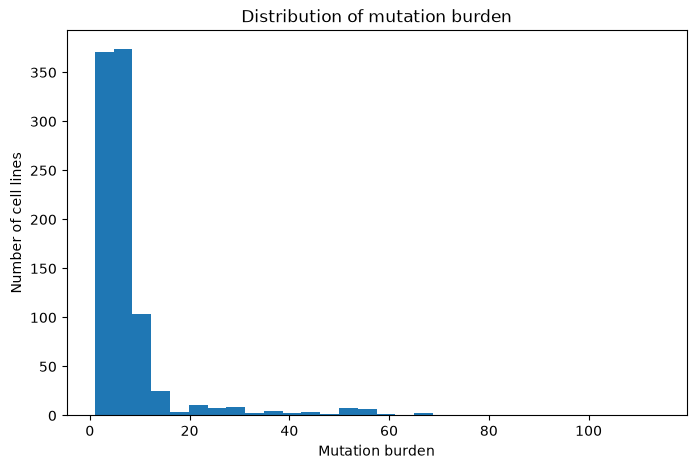

In [9]:

plt.figure(figsize=(8, 5))
plt.hist(mutation_burden, bins=30)
plt.xlabel("Mutation burden")
plt.ylabel("Number of cell lines")
plt.title("Distribution of mutation burden")
plt.show()

### Incorporation of Mutation Burden into the Feature Matrix

Following validation, mutation burden was incorporated into the feature matrix as an additional predictor alongside the binary gene mutation features.

In [10]:
# Create a copy of the binary gene matrix
X_features = gene_matrix.copy()

# Add mutation burden
X_features["Mutation_Burden"] = mutation_burden

In [11]:
print(f"Feature matrix shape: {X_features.shape}")

print(f"Missing mutation burden values: {X_features['Mutation_Burden'].isna().sum()}")

Feature matrix shape: (948, 598)
Missing mutation burden values: 0


### Engineering the MAPK Mutation Burden Feature

Because Trametinib inhibits MEK1/2 within the MAPK signalling pathway, the number of mutated MAPK-related genes was calculated for each cancer cell line. This feature provides a pathway-level summary of genomic alterations directly relevant to Trametinib mechanism of action and may capture biological information not represented by individual gene features alone.

In [12]:
mapk_pathway_gene_set = {
    "KRAS", "NRAS", "HRAS",
    "NF1", "RASA1", "RASA2", "RASA3", "RASA4",
    "BRAF", "RAF1", "ARAF",
    "MAP2K1", "MAP2K2",
    "MAPK1", "MAPK3",
    "EGFR", "ERBB2", "ERBB3", "ERBB4",
    "FGFR1", "FGFR2", "FGFR3", "FGFR4",
    "MET", "KIT", "PDGFRA", "PDGFRB",
    "ALK", "RET", "ROS1",
    "SOS1", "SOS2", "GRB2", "SHC1",
    "DUSP4", "DUSP5", "DUSP6",
    "SPRY1", "SPRY2", "SPRY4",
    "MAP3K1", "MAP3K2", "MAP3K3", "MAP3K4",
    "MAP3K5", "MAP3K7", "MAP3K8",
    "MAP2K3", "MAP2K4", "MAP2K5", "MAP2K6", "MAP2K7",
    "MAPK7", "MAPK8", "MAPK9", "MAPK10",
    "MAPK11", "MAPK12", "MAPK13", "MAPK14"
}

mapk_mutation_burden = (
    merged_gene_level[
        merged_gene_level["gene_symbol"].isin(mapk_pathway_gene_set)
    ]
    .groupby("SANGER_MODEL_ID")
    .size()
    .reindex(gene_matrix.index, fill_value=0)
    .rename("MAPK_Mutation_Burden")
)

In [13]:
print(f"Number of cell lines: {mapk_mutation_burden.shape[0]}")
print(f"Missing values: {mapk_mutation_burden.isna().sum()}")

display(mapk_mutation_burden.describe())

Number of cell lines: 948
Missing values: 0


count    948.000000
mean       0.580169
std        0.803180
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        6.000000
Name: MAPK_Mutation_Burden, dtype: float64

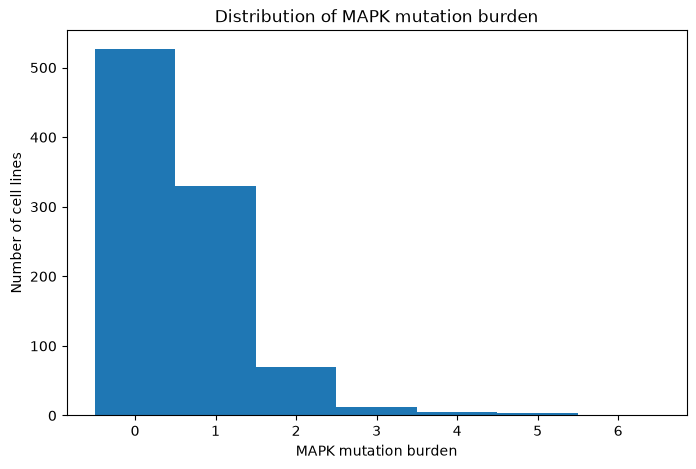

In [14]:
plt.figure(figsize=(8, 5))

plt.hist(
    mapk_mutation_burden,
    bins=range(
        int(mapk_mutation_burden.max()) + 2
    ),
    align="left"
)

plt.xlabel("MAPK mutation burden")
plt.ylabel("Number of cell lines")
plt.title("Distribution of MAPK mutation burden")
plt.show()

### Validation of the MAPK Mutation Burden Feature

The engineered MAPK mutation burden showed the expected right-skewed distribution. Most cancer cell lines contained no mutations within the predefined MAPK gene set, whereas a smaller subset carried one or more pathway alterations. This distribution is consistent with the biological expectation that MAPK pathway mutations occur in a subset of tumours rather than universally. No missing values or implausible observations were identified, and the feature was therefore retained for machine learning.

### Incorporation of MAPK Mutation Burden into the Feature Matrix

Following validation, MAPK mutation burden was incorporated into the feature matrix as a pathway-level predictor relevant to Trametinib mechanism of action.

In [15]:
X_features["MAPK_Mutation_Burden"] = mapk_mutation_burden

In [16]:
print(f"Feature matrix shape: {X_features.shape}")

print(
    f"Missing MAPK mutation burden values: "
    f"{X_features['MAPK_Mutation_Burden'].isna().sum()}"
)

Feature matrix shape: (948, 599)
Missing MAPK mutation burden values: 0


### Incorporation of Cancer Type

In addition to genomic features, cancer type was retained as a predictor because tissue lineage is known before treatment and may influence response to targeted therapies. This variable provides complementary biological information that is not captured by mutation status alone. As cancer type is a categorical variable, it will be encoded after the train-test split to prevent data leakage.

In [17]:
cancer_type = (
    merged_gene_level
    .drop_duplicates(subset="SANGER_MODEL_ID")
    .set_index("SANGER_MODEL_ID")["CANCER_TYPE"]
)

In [18]:
print(f"Number of cell lines: {cancer_type.shape[0]}")

print(f"Missing values: {cancer_type.isna().sum()}")

print(cancer_type.value_counts().head())

Number of cell lines: 948
Missing values: 0
CANCER_TYPE
Non-Small Cell Lung Carcinoma    88
Small Cell Lung Carcinoma        57
Melanoma                         54
Breast Carcinoma                 50
Colorectal Carcinoma             48
Name: count, dtype: int64


In [19]:
X_features["CANCER_TYPE"] = cancer_type

In [20]:
print(X_features.shape)

(948, 600)


## Validation of the Final Feature Matrix

Following feature engineering, the complete feature matrix was validated to confirm the expected dimensions, ensure that no missing values had been introduced during feature integration, and verify that each observation continued to represent a unique cancer cell line. These checks ensure the dataset is suitable for machine learning prior to defining the target variable and performing the train-test split.

In [21]:
print(f"Feature matrix shape: {X_features.shape}")

print(f"Unique cell lines: {X_features.index.nunique()}")

print(f"Missing values: {X_features.isna().sum().sum()}")

print(f"Duplicate indices: {X_features.index.duplicated().sum()}")

Feature matrix shape: (948, 600)
Unique cell lines: 948
Missing values: 0
Duplicate indices: 0


In [22]:
X_features.info()

<class 'pandas.DataFrame'>
Index: 948 entries, SIDM00003 to SIDM01265
Columns: 600 entries, ABCB1 to CANCER_TYPE
dtypes: int64(599), str(1)
memory usage: 4.3+ MB


The completed feature matrix contained 948 observations and 600 predictor variables with no missing values or duplicate observations. The dataset comprised 597 binary gene mutation features, two engineered numerical features (mutation burden and MAPK mutation burden), and one categorical feature (cancer type). Following validation, the feature matrix was considered suitable for supervised machine learning.

# Model Development

The validated feature matrix was used to develop supervised machine learning models to predict Trametinib sensitivity (LN_IC50). Prior to model training, the predictor variables (X) and target variable (y) were defined and validated before the dataset was partitioned into independent training and test sets.

## Definition of Predictor and Target Variables

The validated feature matrix was separated into predictor variables (X) and the target variable (y). The predictors comprised binary gene mutation features, mutation burden, MAPK mutation burden and cancer type, while the target variable was the continuous LN_IC50 value representing Trametinib sensitivity. Separating the predictors and target before data partitioning ensures a clear distinction between input features and the response variable throughout the machine learning workflow.

In [23]:
# Create the target variable (one LN_IC50 value per cell line)

y = (
    merged_gene_level
    .drop_duplicates(subset="SANGER_MODEL_ID")
    .set_index("SANGER_MODEL_ID")["LN_IC50"]
)

# Predictor matrix
X = X_features.copy()

In [24]:
print(f"Predictor matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

print(f"Predictor rows equal target rows: {len(X) == len(y)}")

print(f"Indices aligned: {X.index.equals(y.index)}")

print(f"Missing target values: {y.isna().sum()}")

Predictor matrix shape: (948, 600)
Target shape: (948,)
Predictor rows equal target rows: True
Indices aligned: False
Missing target values: 0


In [25]:
print(X.index[:10])

print(y.index[:10])

Index(['SIDM00003', 'SIDM00023', 'SIDM00040', 'SIDM00042', 'SIDM00043',
       'SIDM00044', 'SIDM00045', 'SIDM00046', 'SIDM00047', 'SIDM00048'],
      dtype='str', name='SANGER_MODEL_ID')
Index(['SIDM01132', 'SIDM00848', 'SIDM00263', 'SIDM00269', 'SIDM00203',
       'SIDM01111', 'SIDM00909', 'SIDM00807', 'SIDM01085', 'SIDM01160'],
      dtype='str', name='SANGER_MODEL_ID')


In [26]:
print(set(X.index) == set(y.index))

True


In [27]:
# Reorder the target so that each LN_IC50 value aligns with the corresponding row in X
y = y.reindex(X.index)

In [28]:
print(f"Predictor matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Predictor rows equal target rows: {len(X) == len(y)}")
print(f"Indices aligned: {X.index.equals(y.index)}")
print(f"Missing target values: {y.isna().sum()}")

Predictor matrix shape: (948, 600)
Target shape: (948,)
Predictor rows equal target rows: True
Indices aligned: True
Missing target values: 0


The predictor and target datasets contained the same 948 cancer cell lines but were initially stored in different row orders. The target variable was therefore reindexed to match the predictor matrix using Sanger Model IDs, ensuring that each feature vector was correctly paired with its corresponding LN_IC50 value before data splitting.

## Train-Test Split

To provide an independent assessment of model performance, the dataset was divided into training and test sets using an 80:20 split. A fixed random state of 42 was used to ensure reproducibility.

The test set was reserved exclusively for final model evaluation and was not used during feature selection, preprocessing, model selection or hyperparameter optimisation. Model validation and hyperparameter tuning will instead be performed using 5-fold cross-validation within the training dataset.

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [30]:
print(f"Training predictors: {X_train.shape}")
print(f"Test predictors: {X_test.shape}")
print(f"Training target: {y_train.shape}")
print(f"Test target: {y_test.shape}")

print(f"\nTraining indices aligned: {X_train.index.equals(y_train.index)}")
print(f"Test indices aligned: {X_test.index.equals(y_test.index)}")

overlap = len(set(X_train.index).intersection(X_test.index))
print(f"Overlap between training and test cell lines: {overlap}")

Training predictors: (758, 600)
Test predictors: (190, 600)
Training target: (758,)
Test target: (190,)

Training indices aligned: True
Test indices aligned: True
Overlap between training and test cell lines: 0


The 80:20 split produced 758 training and 190 test observations, with predictor and target indices correctly aligned and no overlap between the two datasets. The test dataset was therefore reserved as an independent hold-out set and will remain untouched until final model evaluation. All subsequent preprocessing, feature selection, model selection and hyperparameter optimisation will be performed using the training data only.

## Exploration of Gene Mutation Frequencies

Before applying feature selection, the frequency of each binary gene mutation feature was examined within the training dataset. This analysis was performed to understand how commonly individual gene mutations occurred and to inform the selection of an appropriate minimum frequency threshold for retaining gene features.

In [31]:
gene_columns = X_train.columns[:597]

gene_counts = X_train[gene_columns].sum().sort_values()

count    597.000000
mean      10.402010
std       24.422165
min        0.000000
25%        2.000000
50%        5.000000
75%       11.000000
max      510.000000
dtype: float64

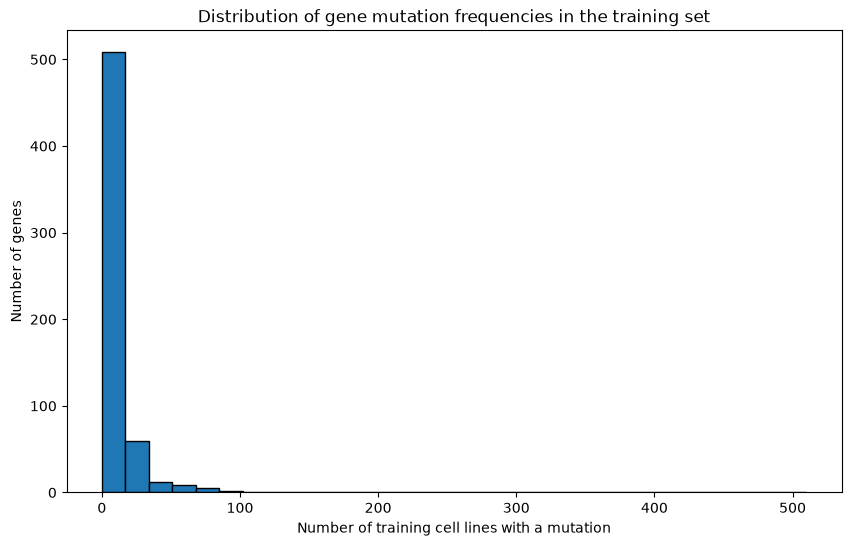

In [32]:
# Select only the binary gene mutation columns
gene_columns = X_train.columns[:597]

# Count the number of mutated cell lines for each gene
gene_counts = X_train[gene_columns].sum()

# Summary statistics
display(gene_counts.describe())

# Histogram
plt.figure(figsize=(10, 6))

plt.hist(
    gene_counts,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Number of training cell lines with a mutation")
plt.ylabel("Number of genes")
plt.title("Distribution of gene mutation frequencies in the training set")

plt.show()

In [33]:
thresholds = [1, 2, 5, 10, 20]

for t in thresholds:
    retained = (gene_counts >= t).sum()
    removed = (gene_counts < t).sum()

    print(
        f"Threshold ≥ {t:2}: "
        f"Retain {retained:3} genes | "
        f"Remove {removed:3} genes"
    )

Threshold ≥  1: Retain 583 genes | Remove  14 genes
Threshold ≥  2: Retain 491 genes | Remove 106 genes
Threshold ≥  5: Retain 329 genes | Remove 268 genes
Threshold ≥ 10: Retain 175 genes | Remove 422 genes
Threshold ≥ 20: Retain  72 genes | Remove 525 genes


In [34]:
gene_counts.value_counts().sort_index().head(10)

0    14
1    92
2    65
3    55
4    42
5    37
6    34
7    35
8    27
9    21
Name: count, dtype: int64

### Selection of a Minimum Gene Frequency Threshold

Before model development, the frequency of each binary gene mutation feature was examined within the training dataset. The distribution was highly right-skewed, with 14 genes absent from the training data, 92 genes occurring in only one cell line, and a further 162 genes occurring in just two to four cell lines.

Rare binary features provide limited statistical evidence for estimating reliable relationships with the target variable, while increasing dataset dimensionality and the risk of overfitting. Several minimum frequency thresholds (≥1, ≥2, ≥5, ≥10 and ≥20 training cell lines) were therefore evaluated. Based on the observed distribution, a threshold of **≥5** was selected, reducing the binary gene feature set from **597 to 329 genes**. This removed 268 extremely rare features while retaining genes with sufficient representation for robust model learning.

The threshold was determined using only the training dataset and the resulting set of retained genes was applied unchanged to the independent test dataset, ensuring feature selection did not introduce data leakage.

### Filtering Low-Frequency Gene Features

The selected minimum frequency threshold was applied to the training dataset to identify binary gene mutation features present in at least five training cell lines. The resulting feature set was then applied unchanged to both the training and test datasets.

In [35]:
# Keep genes mutated in at least 5 training cell lines
retained_gene_columns = gene_counts[gene_counts >= 5].index

print(f"Genes retained: {len(retained_gene_columns)}")
print(f"Genes removed: {len(gene_columns) - len(retained_gene_columns)}")

Genes retained: 329
Genes removed: 268


## Create the Filtered Dataset

In [36]:
X_train_filtered = X_train[
    retained_gene_columns.tolist() +
    [
        "Mutation_Burden",
        "MAPK_Mutation_Burden",
        "CANCER_TYPE"
    ]
].copy()

X_test_filtered = X_test[
    retained_gene_columns.tolist() +
    [
        "Mutation_Burden",
        "MAPK_Mutation_Burden",
        "CANCER_TYPE"
    ]
].copy()

In [37]:
print(f"Training shape: {X_train_filtered.shape}")
print(f"Test shape: {X_test_filtered.shape}")

print(f"Training columns equal test columns: {list(X_train_filtered.columns) == list(X_test_filtered.columns)}")

print(f"Missing values (training): {X_train_filtered.isna().sum().sum()}")
print(f"Missing values (test): {X_test_filtered.isna().sum().sum()}")

Training shape: (758, 332)
Test shape: (190, 332)
Training columns equal test columns: True
Missing values (training): 0
Missing values (test): 0


The selected frequency threshold was successfully applied to the training dataset, reducing the binary gene feature set from 597 to 329 genes. The same retained gene set was subsequently applied to the independent test dataset, ensuring that both datasets contained an identical feature space while preventing information from the test set influencing feature selection. Following filtering, the predictor matrices contained 332 features, comprising 329 binary gene mutation features, mutation burden, MAPK mutation burden and cancer type, and were considered suitable for subsequent preprocessing and model development.

## Feature Preprocessing

Before model training, the predictor data required preprocessing to ensure compatibility with the selected machine learning algorithms while preventing data leakage. As the feature matrix contained both binary, numerical and categorical variables, different preprocessing strategies were required for each feature type.

The binary gene mutation features were filtered using a predefined minimum frequency threshold determined from the training dataset. Mutation burden and MAPK mutation burden were retained as continuous numerical variables, while cancer type was converted to a numerical representation using one-hot encoding.

To ensure that preprocessing was performed independently within each cross-validation fold, all preprocessing steps were incorporated into scikit-learn pipelines rather than being applied globally before model training. The independent test dataset remained excluded from preprocessing, model selection and hyperparameter optimisation until final model evaluation.

### Preprocessing Pipeline

Cancer type was one-hot encoded because it is a nominal categorical variable with no inherent ordering. Binary gene mutation features were retained without scaling, while the two continuous engineered features were standardised for models that are sensitive to feature magnitude. All preprocessing steps were incorporated into scikit-learn pipelines so that transformations were fitted using training data only.

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

categorical_features = ["CANCER_TYPE"]

continuous_features = [
    "Mutation_Burden",
    "MAPK_Mutation_Burden"
]

gene_features = [
    column for column in X_train_filtered.columns
    if column not in categorical_features + continuous_features
]

print(f"Gene features: {len(gene_features)}")
print(f"Continuous features: {len(continuous_features)}")
print(f"Categorical features: {len(categorical_features)}")

Gene features: 329
Continuous features: 2
Categorical features: 1


Create scaled preprocessing object

In [39]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "genes",
            "passthrough",
            gene_features
        ),
        (
            "continuous",
            StandardScaler(),
            continuous_features
        ),
        (
            "cancer_type",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

Create second unscaled preprocessing object for tree models

In [40]:
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "genes",
            "passthrough",
            gene_features
        ),
        (
            "continuous",
            "passthrough",
            continuous_features
        ),
        (
            "cancer_type",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

### Validation of the Preprocessing Pipelines

The preprocessing pipelines were validated using the training dataset to confirm that categorical encoding, feature passthrough and numerical scaling were applied correctly before model training. Validation at this stage ensures that the transformed feature matrices have the expected dimensions and contain no missing values.

In [41]:
X_train_scaled = preprocessor_scaled.fit_transform(X_train_filtered)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train_filtered)

In [42]:
print(f"Scaled training matrix shape: {X_train_scaled.shape}")
print(f"Unscaled training matrix shape: {X_train_unscaled.shape}")

Scaled training matrix shape: (758, 373)
Unscaled training matrix shape: (758, 373)


In [43]:
print(f"Missing values (scaled): {np.isnan(X_train_scaled).sum()}")
print(f"Missing values (unscaled): {np.isnan(X_train_unscaled).sum()}")

Missing values (scaled): 0
Missing values (unscaled): 0


In [44]:
encoder = preprocessor_scaled.named_transformers_["cancer_type"]

print(f"Number of cancer types: {len(encoder.categories_[0])}")
print(encoder.categories_[0])

Number of cancer types: 42
['Acute Myeloid Leukemia' "B-Cell Non-Hodgkin's Lymphoma"
 'B-Lymphoblastic Leukemia' 'Biliary Tract Carcinoma' 'Bladder Carcinoma'
 'Breast Carcinoma' "Burkitt's Lymphoma" 'Cervical Carcinoma'
 'Chondrosarcoma' 'Chronic Myelogenous Leukemia' 'Colorectal Carcinoma'
 'Endometrial Carcinoma' 'Esophageal Carcinoma'
 'Esophageal Squamous Cell Carcinoma' "Ewing's Sarcoma"
 'Gastric Carcinoma' 'Glioblastoma' 'Glioma' 'Head and Neck Carcinoma'
 'Hepatocellular Carcinoma' "Hodgkin's Lymphoma" 'Kidney Carcinoma'
 'Melanoma' 'Mesothelioma' 'Neuroblastoma' 'Non-Cancerous'
 'Non-Small Cell Lung Carcinoma' 'Oral Cavity Carcinoma' 'Osteosarcoma'
 'Other Blood Cancers' 'Other Sarcomas' 'Other Solid Cancers'
 'Ovarian Carcinoma' 'Pancreatic Carcinoma' 'Plasma Cell Myeloma'
 'Prostate Carcinoma' 'Rhabdomyosarcoma' 'Small Cell Lung Carcinoma'
 'Squamous Cell Lung Carcinoma' "T-Cell Non-Hodgkin's Lymphoma"
 'T-Lymphoblastic Leukemia' 'Thyroid Gland Carcinoma']


## Model Evaluation Strategy

All machine learning models were evaluated using the same performance metrics to enable fair comparison. Model development and hyperparameter optimisation were performed using 5-fold cross-validation on the training dataset, while the independent test dataset was reserved for final performance assessment.

The following evaluation metrics were reported:

- Cross-validation R² (mean ± standard deviation)
- Test R²
- Test Mean Absolute Error (MAE)
- Test Root Mean Squared Error (RMSE)

This strategy provides an assessment of both model generalisation during training and predictive performance on previously unseen data.

In [45]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Model Evaluation Function

To ensure consistency across all machine learning models, a reusable evaluation function was implemented. This function performs cross-validation using the training dataset, fits the model to the complete training set, evaluates performance on the independent test set, and returns the evaluation metrics used throughout the project.

In [46]:
def evaluate_model(
    model_name,
    pipeline,
    X_train,
    X_test,
    y_train,
    y_test,
    cv
):
    """
    Evaluate a machine learning model using
    cross-validation and an independent test set.
    """

    # Cross-validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="r2"
    )

    # Train final model
    pipeline.fit(X_train, y_train)

    # Predict test set
    y_pred = pipeline.predict(X_test)

    # Performance metrics
    results = {
        "Model": model_name,
        "CV R² Mean": cv_scores.mean(),
        "CV R² SD": cv_scores.std(),
        "Test R²": r2_score(y_test, y_pred),
        "Test MAE": mean_absolute_error(y_test, y_pred),
        "Test RMSE": root_mean_squared_error(y_test, y_pred)
    }

    return results

### Model Comparison Table

To facilitate comparison between machine learning algorithms, evaluation metrics from each model were stored in a single results table. This provides a consistent summary of model performance across cross-validation and the independent test dataset.

In [47]:
model_results = []

In [48]:
def update_results_table(model_results):
    return (
        pd.DataFrame(model_results)
        .round(3)
        .sort_values("Test R²", ascending=False)
        .reset_index(drop=True)
        .rename_axis("Rank")
    )

## Baseline Model: Linear Regression

Linear Regression was selected as the baseline model because it provides a simple, interpretable benchmark against which the performance of more complex machine learning algorithms can be compared. Although drug response is unlikely to be explained entirely by linear relationships, establishing a baseline allows the value of increasingly sophisticated models to be objectively assessed.

In [49]:
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_scaled),
        ("model", LinearRegression())
    ]
)

linear_results = evaluate_model(
    model_name="Linear Regression",
    pipeline=linear_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

# 3. Store the results
model_results.append(linear_results)

# 4. Update the comparison table
results_df = (
    pd.DataFrame(model_results)
    .round(3)
    .sort_values("Test R²", ascending=False)
    .reset_index(drop=True)
)

results_df.index += 1
results_df.index.name = "Rank"

# 5. Display the updated table
results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
1,Linear Regression,-2.585,1.57,-0.603,2.021,2.821


The baseline Linear Regression model showed poor predictive performance, with a mean cross-validation R² of -2.58 and a test R² of -0.60. Negative R² values indicate that the model performed worse than predicting the mean LN_IC50 value. This suggests that Trametinib response is not adequately captured by a simple additive linear relationship between the selected genomic and cancer-type features, providing a useful baseline against which more flexible nonlinear models can be compared.

## Decision Tree Regression

Decision Tree Regression was selected as the first nonlinear model because it can capture threshold effects and complex interactions between genomic features without assuming a linear relationship between predictors and drug response. Unlike Linear Regression, decision trees partition the feature space into regions with similar outcomes, allowing more flexible modelling of biological relationships.

In [50]:
from sklearn.tree import DecisionTreeRegressor

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_unscaled),
        (
            "model",
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)

decision_tree_results = evaluate_model(
    model_name="Decision Tree",
    pipeline=decision_tree_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(decision_tree_results)

results_df = update_results_table(model_results)

results_df



,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
1,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


The baseline Decision Tree Regressor demonstrated improved performance compared with Linear Regression across all evaluation metrics. The mean cross-validation R² improved from -2.58 to -0.26, while the test R² increased from -0.60 to -0.42. Test MAE and RMSE also decreased, indicating more accurate predictions.

This improvement suggests that nonlinear relationships and interactions between genomic features contribute to Trametinib response. However, the model continued to show poor generalisation, indicating that the default Decision Tree configuration was unlikely to represent the optimal model complexity. Hyperparameter optimisation was therefore performed to improve predictive performance while reducing overfitting.

### Hyperparameter Optimisation

In [51]:
decision_tree_param_grid = {
    "model__max_depth": [3, 5, 10, 20, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": [None, "sqrt", "log2"]
}

In [52]:
grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=decision_tree_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

In [53]:
grid_search.fit(
    X_train_filtered,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 5, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... 

In [54]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'model__max_depth': 5, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}
0.23369688661257354


### Hyperparameter Optimisation Results

Hyperparameter optimisation substantially improved the Decision Tree model. The optimal model limited tree depth to five levels while requiring a minimum of five samples per terminal node. These constraints reduce model complexity and help prevent overfitting, leading to improved generalisation during cross-validation. The tuned model was subsequently evaluated on the independent test dataset to determine whether these improvements translated to previously unseen data.

In [55]:
best_decision_tree = grid_search.best_estimator_

tuned_decision_tree_results = evaluate_model(
    model_name="Decision Tree (Tuned)",
    pipeline=best_decision_tree,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(tuned_decision_tree_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
1,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
2,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


The tuned Decision Tree substantially outperformed both the baseline Decision Tree and the Linear Regression model. Hyperparameter optimisation increased the mean cross-validation R² from -0.264 to 0.234 and improved the independent test R² from -0.424 to 0.279. Test MAE and RMSE were also reduced by approximately 28–29%, indicating more accurate predictions on previously unseen cell lines.

The optimal model employed a relatively shallow tree (maximum depth = 5) with a minimum of five samples per terminal node, suggesting that restricting model complexity improved generalisation and reduced overfitting. These findings demonstrate the importance of hyperparameter optimisation when applying tree-based machine learning algorithms to high-dimensional genomic datasets.

## Random Forest Regression

Random Forest Regression was selected as an ensemble-based extension of the Decision Tree model. By combining predictions from multiple decision trees trained on different bootstrap samples and subsets of features, Random Forest can reduce the variance and overfitting associated with a single decision tree while retaining the ability to model nonlinear relationships and interactions between genomic features.

Because tree-based models are not sensitive to feature scaling, the unscaled preprocessing pipeline was used.

In [56]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_unscaled),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [57]:
random_forest_results = evaluate_model(
    model_name="Random Forest",
    pipeline=random_forest_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(random_forest_results)

results_df = pd.DataFrame(model_results).round(3)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
0,Linear Regression,-2.585,1.570,-0.603,2.021,2.821
1,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
2,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
3,Random Forest,0.303,0.078,0.303,1.361,1.861


The baseline Random Forest model achieved the strongest predictive performance observed so far. Compared with the tuned Decision Tree, the Random Forest further improved both cross-validation and independent test performance, increasing the mean cross-validation R² from 0.234 to 0.303 and the test R² from 0.279 to 0.303.

The close agreement between cross-validation and test performance suggests that the model generalises well to previously unseen cell lines. These findings are consistent with the expected behaviour of Random Forests, which reduce the variance associated with individual decision trees through bootstrap aggregation (bagging) while retaining the ability to model complex nonlinear relationships.

### Random Forest Hyperparameter Optimisation

The baseline Random Forest achieved the strongest performance observed so far. Hyperparameter optimisation was therefore performed using 5-fold cross-validation to investigate whether model performance could be improved further. Parameters controlling the number of trees, tree depth, minimum samples required for splitting and terminal nodes, and the number of features considered at each split were evaluated.

In [58]:
random_forest_param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [5, 10, 20, None],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 5],
    "model__max_features": ["sqrt", "log2", None]
}

random_forest_grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=random_forest_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

random_forest_grid_search.fit(
    X_train_filtered,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score.

In [59]:
print("Best parameters:")
print(random_forest_grid_search.best_params_)

print(
    f"\nBest cross-validation R²: "
    f"{random_forest_grid_search.best_score_:.3f}"
)

Best parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 500}

Best cross-validation R²: 0.355


In [60]:
best_random_forest = random_forest_grid_search.best_estimator_

tuned_random_forest_results = evaluate_model(
    model_name="Random Forest (Tuned)",
    pipeline=best_random_forest,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(tuned_random_forest_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
1,Random Forest,0.303,0.078,0.303,1.361,1.861
2,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
3,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
4,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


### Hyperparameter Optimisation Results

Hyperparameter optimisation produced a further improvement in Random Forest performance across both cross-validation and the independent test dataset. The tuned Random Forest achieved the highest predictive performance observed so far, increasing the mean cross-validation R² from 0.303 to 0.355 and the test R² from 0.303 to 0.328. Test MAE and RMSE also decreased, indicating more accurate prediction of Trametinib sensitivity.

These results suggest that careful optimisation of ensemble parameters further improves model generalisation and reinforces the suitability of tree-based ensemble methods for modelling complex genomic predictors of drug response.

In [61]:
best_rf_params = pd.DataFrame(
    [random_forest_grid_search.best_params_]
)

best_rf_params

,model__max_depth,model__max_features,model__min_samples_leaf,model__min_samples_split,model__n_estimators
0,None,sqrt,2,2,500


The optimal Random Forest consisted of 500 decision trees, with each tree considering the square root of the available features at each split. Individual trees were allowed to grow without a maximum depth constraint, while requiring a minimum of two samples in each terminal node. These hyperparameters produced the strongest predictive performance observed in this study, indicating that a large ensemble of diverse decision trees was able to capture complex nonlinear relationships between genomic alterations and Trametinib response while maintaining good generalisation to previously unseen cell lines.

## Gradient Boosting Regression

Gradient Boosting Regression was selected as a sequential ensemble learning algorithm that builds decision trees iteratively, with each new tree attempting to correct the prediction errors made by the previous ensemble. Unlike Random Forest, which constructs trees independently using bootstrap aggregation, Gradient Boosting focuses on progressively reducing residual error and can often achieve superior predictive performance through careful optimisation of weak learners.

As with the previous tree-based models, feature scaling was not required and the unscaled preprocessing pipeline was used.

In [62]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_unscaled),
        (
            "model",
            GradientBoostingRegressor(
                random_state=42
            )
        )
    ]
)

In [63]:
gradient_boosting_results = evaluate_model(
    model_name="Gradient Boosting",
    pipeline=gradient_boosting_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(gradient_boosting_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
1,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
2,Random Forest,0.303,0.078,0.303,1.361,1.861
3,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
4,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
5,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


The baseline Gradient Boosting model achieved the highest independent test performance observed so far, with a test R² of 0.363 and the lowest MAE and RMSE of all models evaluated. Although the tuned Random Forest achieved a marginally higher cross-validation R², Gradient Boosting demonstrated superior predictive performance on the independent test dataset.

This result suggests that sequential boosting of weak learners may better capture the complex nonlinear relationships underlying Trametinib response than bootstrap aggregation alone. Hyperparameter optimisation was subsequently performed to determine whether Gradient Boosting performance could be improved further.

In [64]:
gradient_boosting_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

gradient_boosting_grid_search = GridSearchCV(
    estimator=gradient_boosting_pipeline,
    param_grid=gradient_boosting_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

gradient_boosting_grid_search.fit(
    X_train_filtered,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2], 'model__min_samples_split': [2, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versio

In [65]:
best_gradient_boosting = gradient_boosting_grid_search.best_estimator_

tuned_gradient_boosting_results = evaluate_model(
    model_name="Gradient Boosting (Tuned)",
    pipeline=best_gradient_boosting,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(tuned_gradient_boosting_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting (Tuned),0.349,0.061,0.376,1.284,1.760
1,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
2,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
3,Random Forest,0.303,0.078,0.303,1.361,1.861
4,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
5,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
6,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


### Tuned Model Performance

Hyperparameter optimisation produced a modest but consistent improvement in Gradient Boosting performance. The tuned model achieved the highest predictive performance of all models evaluated, increasing the independent test R² from 0.363 to 0.376 while also reducing both MAE and RMSE.

The tuned Gradient Boosting model therefore represents the best-performing algorithm evaluated in this study and demonstrates that sequential boosting of weak learners is well suited to modelling the complex nonlinear relationships between genomic alterations and Trametinib response.

## XGBoost

Given the strong performance of Gradient Boosting, XGBoost was evaluated as an advanced gradient boosting implementation incorporating regularisation, shrinkage and efficient tree construction.

In [69]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_unscaled),
        (
            "model",
            XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [70]:
xgboost_results = evaluate_model(
    model_name="XGBoost",
    pipeline=xgboost_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(xgboost_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting (Tuned),0.349,0.061,0.376,1.284,1.760
1,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
2,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
3,Random Forest,0.303,0.078,0.303,1.361,1.861
4,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
5,XGBoost,0.259,0.066,0.269,1.376,1.905
6,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
7,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


The baseline XGBoost model was evaluated to determine whether an advanced implementation of gradient boosting could improve predictive performance compared with the previously evaluated ensemble methods. As XGBoost contains several important hyperparameters controlling model complexity and regularisation, optimisation was subsequently performed using GridSearchCV.

### Hyperparameter Optimisation

Hyperparameter optimisation was performed using 5-fold cross-validation. The search investigated the influence of tree depth, learning rate, number of boosting iterations, row subsampling, column subsampling and minimum child weight on predictive performance.

In [73]:
xgboost_param_grid = {
    "model__n_estimators": [300, 500],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3]
}

In [74]:
xgboost_grid_search = GridSearchCV(
    estimator=xgboost_pipeline,
    param_grid=xgboost_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

xgboost_grid_search.fit(
    X_train_filtered,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8, 1.0], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__min_child_weight': [1, 3], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchang

In [75]:
print("Best parameters:")
print(xgboost_grid_search.best_params_)

print(
    f"\nBest cross-validation R²: "
    f"{xgboost_grid_search.best_score_:.3f}"
)

Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}

Best cross-validation R²: 0.352


In [77]:
best_xgboost_params = pd.DataFrame(
    [xgboost_grid_search.best_params_]
)

best_xgboost_params

,model__colsample_bytree,model__learning_rate,model__max_depth,model__min_child_weight,model__n_estimators,model__subsample
0,0.8,0.05,3,3,300,0.8


### Interpretation of Optimal Hyperparameters

The optimal XGBoost model used relatively shallow trees (maximum depth = 3) together with a reduced learning rate of 0.05 and 300 boosting iterations. Both row and feature subsampling were set to 0.8, introducing additional regularisation by training individual trees on subsets of the available observations and predictors. A minimum child weight of 3 further constrained tree growth.

Together, these settings indicate that the best-performing XGBoost configuration favoured a moderately regularised model rather than highly complex individual trees. The tuned model achieved a cross-validation R² of 0.352, indicating substantially improved generalisation compared with the baseline XGBoost model.

In [78]:
best_xgboost = xgboost_grid_search.best_estimator_

tuned_xgboost_results = evaluate_model(
    model_name="XGBoost (Tuned)",
    pipeline=best_xgboost,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(tuned_xgboost_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting (Tuned),0.349,0.061,0.376,1.284,1.760
1,XGBoost (Tuned),0.352,0.076,0.367,1.270,1.773
2,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
3,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
4,Random Forest,0.303,0.078,0.303,1.361,1.861
5,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
6,XGBoost,0.259,0.066,0.269,1.376,1.905
7,Decision Tree,-0.264,0.107,-0.424,1.929,2.659
8,Linear Regression,-2.585,1.570,-0.603,2.021,2.821


### Comparison of Gradient Boosting and XGBoost

The tuned XGBoost model achieved performance comparable to the tuned Gradient Boosting model, producing a cross-validation R² of 0.352 and an independent test R² of 0.367. Although XGBoost achieved the lowest mean absolute error (MAE = 1.270), the tuned Gradient Boosting model retained the highest test R² (0.376) and the lowest RMSE (1.760), indicating slightly superior overall predictive performance.

These findings suggest that both boosting algorithms effectively captured nonlinear relationships within the genomic feature set. However, the additional regularisation and optimisation strategies implemented within XGBoost did not translate into a clear improvement over the classical Gradient Boosting implementation for this dataset.

## Neural Network Regression
 Neural Networks were evaluated as a flexible nonlinear modelling approach capable of learning complex relationships between genomic features and Trametinib response. Unlike tree-based methods, neural networks learn hierarchical feature representations through multiple interconnected layers of neurons, allowing complex nonlinear interactions to be modelled directly from the data.

As neural networks are sensitive to the scale of input features, the scaled preprocessing pipeline was used.

In [80]:
neural_network_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_scaled),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(100,),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [81]:
neural_network_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor_scaled),
        (
            "model",
            MLPRegressor(
                hidden_layer_sizes=(100,),
                activation="relu",
                solver="adam",
                alpha=0.0001,
                learning_rate_init=0.001,
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [82]:
neural_network_results = evaluate_model(
    model_name="Neural Network",
    pipeline=neural_network_pipeline,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(neural_network_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting (Tuned),0.349,0.061,0.376,1.284,1.760
1,XGBoost (Tuned),0.352,0.076,0.367,1.270,1.773
2,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
3,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
4,Random Forest,0.303,0.078,0.303,1.361,1.861
5,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
6,XGBoost,0.259,0.066,0.269,1.376,1.905
7,Neural Network,0.017,0.157,-0.202,1.835,2.443
8,Decision Tree,-0.264,0.107,-0.424,1.929,2.659


### Hyperparameter Optimisation

Hyperparameter optimisation investigated the influence of network architecture, regularisation strength and learning rate on predictive performance. Optimisation was performed using 5-fold cross-validation.

In [84]:
neural_network_param_grid = {
    "model__hidden_layer_sizes": [
        (50,),
        (100,),
        (100, 50)
    ],
    "model__alpha": [
        0.0001,
        0.001,
        0.01
    ],
    "model__learning_rate_init": [
        0.001,
        0.01
    ]
}

In [85]:
neural_network_grid_search = GridSearchCV(
    estimator=neural_network_pipeline,
    param_grid=neural_network_param_grid,
    cv=cv,
    scoring="r2",
    n_jobs=-1
)

neural_network_grid_search.fit(
    X_train_filtered,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.0001, 0.001, ...], 'model__hidden_layer_sizes': [(50,), (100,), ...], 'model__learning_rate_init': [0.001, 0.01]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Sup

In [86]:
print("Best parameters:")
print(neural_network_grid_search.best_params_)

print(
    f"\nBest cross-validation R²: "
    f"{neural_network_grid_search.best_score_:.3f}"
)

Best parameters:
{'model__alpha': 0.01, 'model__hidden_layer_sizes': (100, 50), 'model__learning_rate_init': 0.01}

Best cross-validation R²: 0.171


In [87]:
best_neural_network_params = pd.DataFrame(
    [neural_network_grid_search.best_params_]
)

best_neural_network_params

,model__alpha,model__hidden_layer_sizes,model__learning_rate_init
0,0.01,"(100, 50)",0.01


In [88]:
best_neural_network = neural_network_grid_search.best_estimator_

tuned_neural_network_results = evaluate_model(
    model_name="Neural Network (Tuned)",
    pipeline=best_neural_network,
    X_train=X_train_filtered,
    X_test=X_test_filtered,
    y_train=y_train,
    y_test=y_test,
    cv=cv
)

model_results.append(tuned_neural_network_results)

results_df = update_results_table(model_results)

results_df

,Model,CV R² Mean,CV R² SD,Test R²,Test MAE,Test RMSE
Rank,,,,,,
0,Gradient Boosting (Tuned),0.349,0.061,0.376,1.284,1.760
1,XGBoost (Tuned),0.352,0.076,0.367,1.270,1.773
2,Gradient Boosting,0.340,0.064,0.363,1.286,1.779
3,Random Forest (Tuned),0.355,0.041,0.328,1.316,1.827
4,Random Forest,0.303,0.078,0.303,1.361,1.861
5,Decision Tree (Tuned),0.234,0.095,0.279,1.382,1.891
6,XGBoost,0.259,0.066,0.269,1.376,1.905
7,Neural Network (Tuned),0.171,0.075,0.055,1.648,2.166
8,Neural Network,0.017,0.157,-0.202,1.835,2.443
